# Sprint 5 - Naive Bayes

A partir del conjunto de datos `ASI_casoPractico.csv`:

1. Enumerar las 3 variables explicativas con mayor correlación con el *target*.
2. Crear conjuntos de entrenamiento (60%) y test (40%).
3. Ajustar un modelo de **Naive Bayes** sobre el conjunto de entrenamiento.
4. Obtener la curva ROC y el AUC para entrenamiento y test.

**Objetivo:** aprender a ajustar el algoritmo de Naive Bayes y validar su precisión a partir de la curva ROC y el área bajo la curva.

In [1]:
# IMPORTACION DE LIBRERIAS
import numpy as np
import pandas as pd

# LIBRERIAS PARA HACER GRAFICOS
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# CARGA DEL FICHERO DE DATOS
from google.colab import files
files.upload()

file = 'ASI_casoPractico.csv'
data = pd.read_csv(file, sep=';', encoding='utf-8-sig')
data.head()

Saving ASI_casoPractico.csv to ASI_casoPractico.csv


,ID,b,e,LBE,AC,FM,UC,ASTV,MSTV,ALTV,...,Min,Max,Nmax,Nzeros,Mode,Mean,Median,Variance,Tendency,Target
0,1,240,357,120,0,0,0,73,0.5,43,...,62,126,2,0,120,137,121,73,1,1
1,2,5,632,132,4,0,4,17,2.1,0,...,68,198,6,1,141,136,140,12,0,0
2,3,177,779,133,2,0,5,16,2.1,0,...,68,198,5,1,141,135,138,13,0,0
3,4,411,1192,134,2,0,6,16,2.4,0,...,53,170,11,0,137,134,137,13,1,0
4,5,533,1147,132,4,0,5,16,2.4,0,...,53,170,9,0,137,136,138,11,1,0


In [4]:
# INFORMACION DEL CONJUNTO DE DATOS
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 26 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   ID        2126 non-null   int64  
 1   b         2126 non-null   int64  
 2   e         2126 non-null   int64  
 3   LBE       2126 non-null   int64  
 4   AC        2126 non-null   int64  
 5   FM        2126 non-null   int64  
 6   UC        2126 non-null   int64  
 7   ASTV      2126 non-null   int64  
 8   MSTV      2126 non-null   float64
 9   ALTV      2126 non-null   int64  
 10  MLTV      2126 non-null   float64
 11  DL        2126 non-null   int64  
 12  DS        2126 non-null   int64  
 13  DP        2126 non-null   int64  
 14  DR        2126 non-null   int64  
 15  Width     2126 non-null   int64  
 16  Min       2126 non-null   int64  
 17  Max       2126 non-null   int64  
 18  Nmax      2126 non-null   int64  
 19  Nzeros    2126 non-null   int64  
 20  Mode      2126 non-null   int6

In [5]:
# ELIMINAR COLUMNAS NO NECESARIAS (identificadores / sin informacion)
data = data.drop(["ID", "b", "e", "DR"], axis=1)
data.head()

,LBE,AC,FM,UC,ASTV,MSTV,ALTV,MLTV,DL,DS,...,Min,Max,Nmax,Nzeros,Mode,Mean,Median,Variance,Tendency,Target
0,120,0,0,0,73,0.5,43,2.4,0,0,...,62,126,2,0,120,137,121,73,1,1
1,132,4,0,4,17,2.1,0,10.4,2,0,...,68,198,6,1,141,136,140,12,0,0
2,133,2,0,5,16,2.1,0,13.4,2,0,...,68,198,5,1,141,135,138,13,0,0
3,134,2,0,6,16,2.4,0,23.0,2,0,...,53,170,11,0,137,134,137,13,1,0
4,132,4,0,5,16,2.4,0,19.9,0,0,...,53,170,9,0,137,136,138,11,1,0


## 1. Variables explicativas con mayor correlación con el target

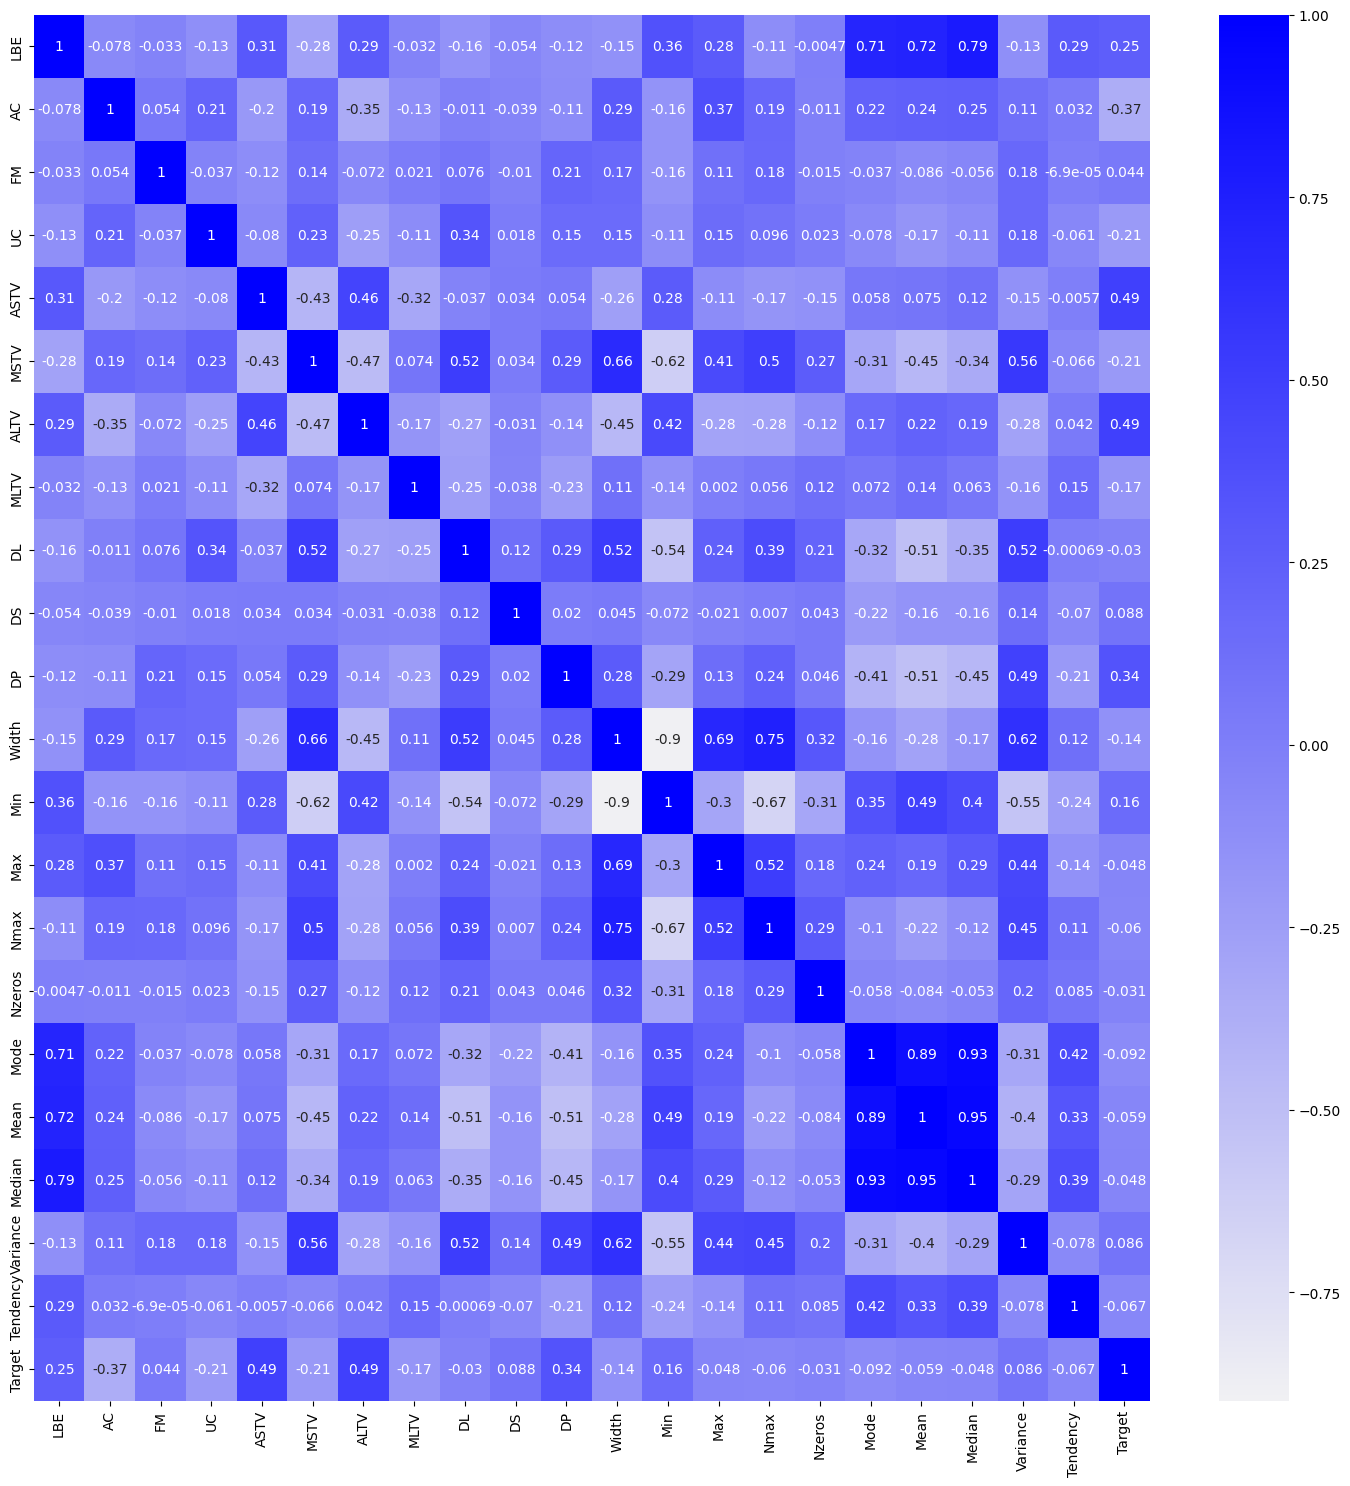

In [6]:
# MATRIZ DE CORRELACIONES
plt.figure(figsize=(18, 18))
corr = data.corr()
cmap = sns.color_palette("light:b", as_cmap=True)
sns.heatmap(corr, annot=True, cmap=cmap)
plt.show()

In [7]:
# CORRELACION DE CADA VARIABLE EXPLICATIVA CON EL TARGET (valor absoluto)
corr_target = data.corr()["Target"].drop("Target")
corr_ranking = corr_target.abs().sort_values(ascending=False)

print("Correlacion (valor absoluto) de cada variable con el Target:\n")
print(corr_ranking)

top3 = corr_ranking.head(3)
print("\nLas 3 variables con mayor correlacion con el Target:")
for var, val in top3.items():
    print(f"  {var}: {corr_target[var]:.3f}")

Correlacion (valor absoluto) de cada variable con el Target:

ASTV        0.493391
ALTV        0.489400
AC          0.369470
DP          0.340647
LBE         0.251875
UC          0.213611
MSTV        0.207717
MLTV        0.172519
Min         0.158171
Width       0.142182
Mode        0.092320
DS          0.087967
Variance    0.085948
Tendency    0.066529
Nmax        0.060354
Mean        0.059107
Max         0.048106
Median      0.047890
FM          0.043953
Nzeros      0.031163
DL          0.029696
Name: Target, dtype: float64

Las 3 variables con mayor correlacion con el Target:
  ASTV: 0.493
  ALTV: 0.489
  AC: -0.369


## 2. Conjuntos de entrenamiento (60%) y test (40%)

In [8]:
# MUESTREO: ENTRENAMIENTO (60%) Y TEST (40%)
from sklearn.model_selection import train_test_split

X = data.loc[:, data.columns != "Target"]
y = data.loc[:, data.columns == "Target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.60, random_state=0
)

print(f"Entrenamiento: {X_train.shape[0]} observaciones ({X_train.shape[0] / len(X):.0%})")
print(f"Test:          {X_test.shape[0]} observaciones ({X_test.shape[0] / len(X):.0%})")

Entrenamiento: 1275 observaciones (60%)
Test:          851 observaciones (40%)


## 3. Ajuste del modelo Naive Bayes

In [10]:
# MODELIZACION
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()
modelNB = gnb.fit(X_train, y_train.values.ravel())

y_pred_train = modelNB.predict_proba(X_train)
y_pred_test = modelNB.predict_proba(X_test)

## 4. Curva ROC y área bajo la curva (AUC)

In [11]:
# VALIDACION
from sklearn.metrics import roc_curve, auc

# CURVA ROC Y AUC PARA TRAINING
fpr_train, tpr_train, _ = roc_curve(y_train, y_pred_train[:, 1])
roc_auc_train = auc(fpr_train, tpr_train)

# CURVA ROC Y AUC PARA TEST
fpr_test, tpr_test, _ = roc_curve(y_test, y_pred_test[:, 1])
roc_auc_test = auc(fpr_test, tpr_test)

print(f"AUC entrenamiento: {roc_auc_train:.4f}")
print(f"AUC test:          {roc_auc_test:.4f}")

AUC entrenamiento: 0.9459
AUC test:          0.9349


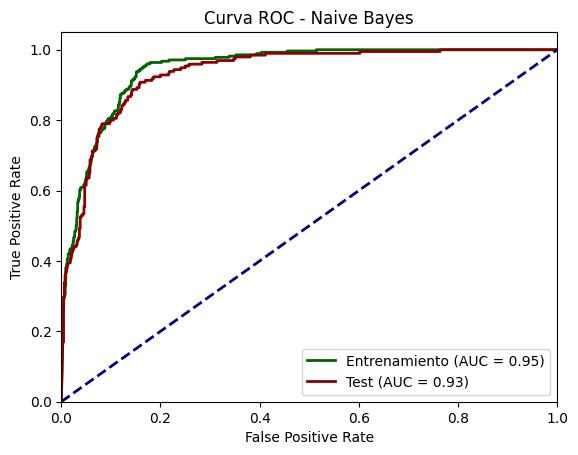

In [12]:
# GRAFICA DE LA CURVA ROC
plt.figure()
lw = 2

plt.plot(fpr_train, tpr_train, color="darkgreen", lw=lw,
         label="Entrenamiento (AUC = %0.2f)" % roc_auc_train)
plt.plot(fpr_test, tpr_test, color="darkred", lw=lw,
         label="Test (AUC = %0.2f)" % roc_auc_test)

plt.plot([0, 1], [0, 1], color="navy", lw=lw, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Naive Bayes")
plt.legend(loc="lower right")
plt.show()

## Conclusiones

- Las **3 variables explicativas con mayor correlación con el target** se obtienen en el paso 1 (ranking por valor absoluto de la correlación).
- El modelo de Naive Bayes se ajustó con el 60% de las observaciones y se validó sobre el 40% restante.
- La comparación del AUC de entrenamiento y test permite valorar la capacidad de generalización: valores similares indican que el modelo no sobreajusta y mantiene una buena precisión.